<a href="https://colab.research.google.com/github/camille2019/Women-Capital-Trial-Analysis/blob/main/exact_matching_groups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>[Install and Import Packages](#scrollTo=pV1c36UWmyHP)

>[Load Data](#scrollTo=FxmVSM3mm15-)

>[Select cols for analysis](#scrollTo=lZDYmiJRnxey)

>[(RQ1) Propensity matching for Crime alone](#scrollTo=drFZk8qqeAkm)

>[RQ1 Course Exact Matching for Crime](#scrollTo=VI-wayzhi56z)

>[Propensity matching for state + race+ crime](#scrollTo=F4TvrOSub6uI)

>[RQ2 Match for Parents](#scrollTo=9MSWJLwTb5xp)

>[RQ3 Match for Victim Relationship (partner or child)](#scrollTo=fTdM67TdcL8K)

>[(RQ4) Prpoensity Match for Race](#scrollTo=VIAO0BvYcPU1)

>[RQ4 Exact Match for Race](#scrollTo=dF5cIorsjWmd)

>[RQ5 Match for All above categories with exact Matching](#scrollTo=PdlRlKt19fb9)

>[Propensity Match for all conditions above](#scrollTo=_P2C9_3ncUjO)

>[Match on rq5 categories  + state and sentencing band](#scrollTo=t-ljQks0RRHB)



#Install and Import Packages

In [1]:
!pip install psmpy


In [2]:
!pip install cem

In [3]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

from psmpy import PsmPy
from psmpy.functions import cohenD
from psmpy.plotting import *

In [4]:
from psmpy import PsmPy
from cem.match import match
from cem.coarsen import coarsen
from cem.imbalance import L1

import statsmodels.api as sm


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Data

In [6]:
save_path = '/content/drive/MyDrive/Capital_trials/'
# full_meta = pd.read_csv(save_path + 'full_crime_meta_.csv')
# ohe_meta = pd.read_csv('/content/drive/MyDrive/Capital_trials/ohe_metadata_only.csv')

ohe_meta = pd.read_csv('/content/ohe_meta.csv')

In [7]:
ohe_meta

,remove,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,...,sentence_band_2020-2024,sentence_band_2070-2074,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,gender_man,gender_woman,parent_binary
0,NaN,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,True,False,0
1,NaN,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,1
2,NaN,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,...,False,False,False,False,False,False,True,True,False,0
3,NaN,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,True,False,1
4,NaN,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,NaN,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,1
154,NaN,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,True,1
155,NaN,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,...,False,False,False,False,True,False,False,False,True,1
156,NaN,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,True,1


In [ ]:
ohe_meta

,remove,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,...,sentence_band_2020-2024,sentence_band_2070-2074,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,gender_man,gender_woman,parent_binary
0,NaN,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,True,False,0
1,NaN,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,1
2,NaN,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,...,False,False,False,False,False,False,True,True,False,0
3,NaN,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,True,False,1
4,NaN,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,NaN,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,True,1
154,NaN,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,True,1
155,NaN,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,...,False,False,False,False,True,False,False,False,True,1
156,NaN,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,...,False,False,False,False,False,False,True,False,True,1


In [8]:
ohe_meta.remove.unique()

array([nan, True], dtype=object)

In [9]:
#remove rows for transcripts that were removed from the legal analysis
ohe_meta = ohe_meta[ohe_meta['remove'] != True]

In [10]:
ohe_meta.columns

Index(['remove', 'filename', 'Name', 'crime_cont_threat',
       'crime_disregard_human_life', 'crime_manner_mayhem',
       'crime_retaliation', 'crime_old_disabled_victim', 'crime_weapon_arson',
       'crime_weapon', 'crime_aggrevated_assult', 'crime_attempted_rape',
       'crime_child_victim', 'crime_public_risk', 'crime_premeditated',
       'crime_multiple_felonies', 'crime_especially_cruel',
       'crime_gang_murder', 'crime_bodily_injury', 'crime_interfere_arrest',
       'crime_kidnapping', 'crime_larceny', 'crime_lewd_acts_child',
       'crime_lying_in_wait', 'crime_police_victim', 'crime_handgun',
       'crime_weapon_poison', 'crime_prior_conv', 'crime_prior_off',
       'crime_rape', 'crime_sexual_assult', 'crime_shooting_car',
       'crime_sodomy', 'crime_torture', 'crime_unlawful_firearm',
       'victim_list', 'victim_child', 'victim_child_care', 'victim_partner',
       'victim_ex_partner', 'victim_stranger', 'victim_family',
       'victim_familiar', 'State_AL', '

In [11]:
ohe_meta.remove.unique()

array([nan], dtype=object)

In [12]:
ohe_meta =  ohe_meta[['filename', 'Name', 'crime_cont_threat',
       'crime_disregard_human_life', 'crime_manner_mayhem',
       'crime_retaliation', 'crime_old_disabled_victim', 'crime_weapon_arson',
       'crime_weapon', 'crime_aggrevated_assult', 'crime_attempted_rape',
       'crime_child_victim', 'crime_public_risk', 'crime_premeditated',
       'crime_multiple_felonies', 'crime_especially_cruel',
       'crime_gang_murder', 'crime_bodily_injury', 'crime_interfere_arrest',
       'crime_kidnapping', 'crime_larceny', 'crime_lewd_acts_child',
       'crime_lying_in_wait', 'crime_police_victim', 'crime_handgun',
       'crime_weapon_poison', 'crime_prior_conv', 'crime_prior_off',
       'crime_rape', 'crime_sexual_assult', 'crime_shooting_car',
       'crime_sodomy', 'crime_torture', 'crime_unlawful_firearm',
       'victim_list', 'victim_child', 'victim_child_care', 'victim_partner',
       'victim_ex_partner', 'victim_stranger', 'victim_family',
       'victim_familiar', 'State_AL', 'State_AZ', 'State_CA', 'State_FL',
       'State_GA', 'State_ID', 'State_KY', 'State_LA', 'State_MS', 'State_NC',
       'State_OH', 'State_OK', 'State_PA', 'State_SC', 'State_TN', 'State_TX',
       'sentence_band_1975-1979', 'sentence_band_1980-1984',
       'sentence_band_1985-1989', 'sentence_band_1990-1994',
       'sentence_band_1995-1999', 'sentence_band_2000-2004',
       'sentence_band_2005-2009', 'sentence_band_2010-2014',
       'sentence_band_2015-2019', 'sentence_band_2020-2024',
       'sentence_band_2070-2074', 'Race_Asian', 'Race_Black', 'Race_Latinx',
       'Race_Native American', 'Race_White', 'gender_man', 'gender_woman',
       'parent_binary']]

In [13]:
ohe_meta.rename(columns={'sentence_band_2070-2074': 'sentence_band_1970-1974'}, inplace=True)

change to multi-racial for Heather Leavell Keaton


In [14]:
ohe_meta['Race_Multiracial'] = False


In [15]:
ohe_meta.loc[ohe_meta['Name'] == 'Heather Leavell Keaton', ['Name','Race_Asian',
       'Race_Black',
            'Race_Latinx',
            'Race_Native American',
            'Race_White', 'Race_Multiracial']]


,Name,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,Race_Multiracial
127,Heather Leavell Keaton,False,True,False,False,False,False


In [16]:
ohe_meta.loc[ohe_meta['Name']  == 'Heather Leavell Keaton', 'Race_Black'] = False
ohe_meta.loc[ohe_meta['Name']  == 'Heather Leavell Keaton', 'Race_Multiracial'] = True
ohe_meta.loc[ohe_meta['Name'] == 'Heather Leavell Keaton',  ['Name' ,'Race_Asian',
       'Race_Black',
            'Race_Latinx',
            'Race_Native American',
            'Race_White', 'Race_Multiracial']]


,Name,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,Race_Multiracial
127,Heather Leavell Keaton,False,False,False,False,False,True


#Select cols for analysis

In [17]:
all_race_cols =['Race_Asian',
       'Race_Black',
            'Race_Latinx',
            'Race_Native American',
            'Race_White',
             'Race_Multiracial' ]

race_cols =['Race_Asian',
       'Race_Black',
            'Race_Latinx',
            'Race_Native American',
            'Race_White',]
            # 'Race_Multiracial' ]

In [18]:
all_state_cols = ['State_AL',
       'State_AZ', 'State_CA',
              'State_FL', 'State_GA', 'State_ID', 'State_KY',
       'State_LA', 'State_MS', 'State_NC',
              'State_OH', 'State_OK', 'State_PA',
       'State_SC', 'State_TN',
                'State_TX']

state_cols = ['State_AL',
       'State_AZ', 'State_CA',
              'State_FL', 'State_GA', 'State_ID', 'State_KY',
       'State_LA', 'State_MS', 'State_NC',
              'State_OH', 'State_OK', 'State_PA',
       'State_SC', 'State_TN']
                # 'State_TX']

In [19]:
crime_cols = ['crime_cont_threat', 'crime_disregard_human_life',
       'crime_manner_mayhem', 'crime_retaliation', 'crime_old_disabled_victim',
       'crime_weapon_arson', 'crime_weapon', 'crime_aggrevated_assult',
       'crime_attempted_rape', 'crime_child_victim', 'crime_public_risk',
       'crime_premeditated', 'crime_multiple_felonies',
       'crime_especially_cruel', 'crime_gang_murder', 'crime_bodily_injury',
       'crime_interfere_arrest', 'crime_kidnapping', 'crime_larceny',
       'crime_lewd_acts_child', 'crime_lying_in_wait', 'crime_police_victim',
       'crime_handgun', 'crime_weapon_poison', 'crime_prior_conv',
       'crime_prior_off', 'crime_rape', 'crime_sexual_assult',
       'crime_shooting_car', 'crime_sodomy', 'crime_torture',
       'crime_unlawful_firearm', ]







In [20]:
weapons_condensed = ['crime_weapon_poison', 'crime_handgun', 'crime_weapon', 'crime_weapon_arson' ,
                     'crime_weapon_poison', 'crime_unlawful_firearm', 'crime_shooting_car']
ohe_meta['crime_condensed_weapon'] = ohe_meta[weapons_condensed].any(axis=1).astype(int)


sex_crimes_consensed = ['crime_sodomy', 'crime_rape',  'crime_lewd_acts_child', 'crime_attempted_rape','crime_sexual_assult' ]
ohe_meta['crime_condensed_sa'] = ohe_meta[sex_crimes_consensed].any(axis=1).astype(int)

premeditated_condensed = ['crime_premeditated', 'crime_lying_in_wait',  'crime_retaliation']
ohe_meta['crime_condensed_premed'] = ohe_meta[premeditated_condensed].any(axis=1).astype(int)

priors_condensed = ['crime_prior_off', 'crime_prior_conv']
ohe_meta['crime_condensed_priors'] = ohe_meta[priors_condensed].any(axis=1).astype(int)

torture_condensed = ['crime_torture', 'crime_especially_cruel', 'crime_manner_mayhem']
ohe_meta['crime_condensed_torture'] = ohe_meta[torture_condensed].any(axis=1).astype(int)

assult_condensed = ['crime_aggrevated_assult', 'crime_bodily_injury', 'crime_disregard_human_life']
ohe_meta['crime_condensed_assult'] = ohe_meta[assult_condensed].any(axis=1).astype(int)

cont_threat_condensd = ['crime_public_risk', 'crime_cont_threat', 'crime_gang_murder', 'crime_multiple_felonies']
ohe_meta['crime_condensed_risk'] = ohe_meta[cont_threat_condensd].any(axis=1).astype(int)

law_enforcement_cond = ['crime_police_victim', 'crime_interfere_arrest']
ohe_meta['crime_condensed_law_enforcement'] = ohe_meta[law_enforcement_cond].any(axis=1).astype(int)

crime_condensed_cols = ['crime_condensed_weapon', 'crime_condensed_sa',
                        'crime_condensed_premed', 'crime_condensed_priors',
                        'crime_condensed_torture','crime_condensed_assult' ,
                        'crime_condensed_risk', 'crime_condensed_law_enforcement']
all_condensed_crime_cols =  law_enforcement_cond + cont_threat_condensd + assult_condensed + torture_condensed + priors_condensed + premeditated_condensed + sex_crimes_consensed + weapons_condensed

In [21]:
non_condensed_crime_cols = list(set(crime_cols) -set(all_condensed_crime_cols))
non_condensed_crime_cols

['crime_larceny',
 'crime_kidnapping',
 'crime_old_disabled_victim',
 'crime_child_victim']

In [88]:
remainder = set(crime_cols) - set(law_enforcement_cond+cont_threat_condensd +assult_condensed+ torture_condensed+ priors_condensed+ premeditated_condensed +sex_crimes_consensed + weapons_condensed)

In [70]:
new_crime_cols = non_condensed_crime_cols + crime_condensed_cols

In [89]:
new_crime_cols = crime_condensed_cols + list(remainder)

In [90]:
new_crime_cols

['crime_condensed_weapon',
 'crime_condensed_sa',
 'crime_condensed_premed',
 'crime_condensed_priors',
 'crime_condensed_torture',
 'crime_condensed_assult',
 'crime_condensed_risk',
 'crime_condensed_law_enforcement',
 'crime_larceny',
 'crime_kidnapping',
 'crime_old_disabled_victim',
 'crime_child_victim']

In [22]:
len(crime_cols)

32

In [23]:
victim_relationship_cols = ['victim_child',
       'victim_child_care', 'victim_partner', 'victim_ex_partner',
       'victim_stranger', 'victim_family', 'victim_familiar']

In [24]:
ohe_meta[(ohe_meta['victim_partner'] ==1) & (ohe_meta['victim_child'] ==1)]

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
135,Manling_Williams.txt,Manling Williams,0,0,0,0,0,0,0,0,...,1,False,0,0,1,1,0,0,0,0
143,Robin_Row.txt,Robin Lee Row,1,1,0,0,0,1,0,0,...,1,False,1,0,0,0,1,1,1,0


In [25]:
all_sentence_band_cols =  [ 'sentence_band_1980-1984', 'sentence_band_1985-1989',
       'sentence_band_1990-1994', 'sentence_band_1995-1999',
       'sentence_band_2000-2004', 'sentence_band_2005-2009',
       'sentence_band_2010-2014', 'sentence_band_2015-2019',
       'sentence_band_2020-2024','sentence_band_1970-1974']

sentence_band_cols  = [ 'sentence_band_1980-1984', 'sentence_band_1985-1989',
       'sentence_band_1990-1994', 'sentence_band_1995-1999',
       'sentence_band_2000-2004', 'sentence_band_2005-2009',
       'sentence_band_2010-2014', 'sentence_band_2015-2019',
       'sentence_band_2020-2024',]

                        # 'sentence_band_1970-1974']

In [26]:
parent_col = ['parent_binary']

In [27]:
victim_close_relationship_strict_cols = ['victim_child', 'victim_partner']
victim_close_relationship_loose_cols = ['victim_child', 'victim_child_care', 'victim_partner', 'victim_ex_partner',]

In [28]:
state_race_crime_cols = state_cols + race_cols + crime_cols

In [29]:
race_crime_cols = race_cols + crime_cols

In [30]:
def add_propensity(propensity_columns, treatment_column, df_encoded, df_meta, matched_group_name, add_score_col= True, cal = None, rep=False,  h_m = 1, m= None, return_pairs = False):

  psm_df = df_encoded[propensity_columns + [treatment_column, 'Name']].copy()


  psm_df = psm_df.reset_index(drop=True)
  psm_df["row_id"] = psm_df.index

  psm = PsmPy(psm_df, treatment=treatment_column, indx="row_id", exclude=['Name'])

  psm.logistic_ps(balance=True)

  if h_m > 1:
    if m is None:
      psm.kdtree_matched_12n(matcher='propensity_logit', how_many = h_m)
      pairs = psm.df_matched

    else:
      psm.kdtree_matched_12n(matcher= m, how_many = h_m )
      pairs = psm.df_matched



  else:
    if m is None:
      psm.kdtree_matched(matcher='propensity_logit', caliper=cal, replacement = rep )
      pairs = psm.df_matched

    else:
      psm.kdtree_matched(matcher=m, caliper=cal, replacement = rep )
      pairs = psm.df_matched



  pred = psm.predicted_data

  df_meta = df_meta.reset_index(drop=True)

  scores_col_name = matched_group_name + '_prop_scores'

  if add_score_col:

    score_map = pred[["row_id", "propensity_score"]].drop_duplicates("row_id")
    df_meta = df_meta.merge(score_map, left_index=True, right_on="row_id", how="left")
    df_meta = df_meta.drop(columns=["row_id"])
    df_meta = df_meta.rename(columns={"propensity_score": matched_group_name + "_prop_scores"})

  # psm.kdtree_matched(matcher="propensity_score", replacement=False, caliper=None)
  # matched_df = psm.df_matched
  # matched_ids = set(psm.df_matched["row_id"].unique())
  # df_meta = df_meta.reset_index(drop=True)

  # binary_col_name = 'psm_' + matched_group_name

  # df_meta[binary_col_name] = df_meta.index.isin(matched_ids)
  matched_ids = set(psm.df_matched["row_id"].unique())
  df_meta[ matched_group_name] = df_meta.index.isin(matched_ids)
  if return_pairs:
    return df_meta, pairs
  else:
    return df_meta



In [ ]:
def find_caliper(updated_df, propensity_score_col):
  updated_df['logit_ps'] = np.log(updated_df[propensity_score_col] / (1 - updated_df[propensity_score_col]))

  std_logit = updated_df['logit_ps'].std()

  caliper = 0.2 * std_logit

  tight_caliper = 0.1 * std_logit

  loose_caliper = 0.5 * std_logit

  print(f"Recommended Caliper (.2 * std): {caliper}")
  print(f"Tight Caliper (.1 * std): {tight_caliper}")
  print(f"Loose Caliper (.5 * std): {loose_caliper}")
  return caliper, tight_caliper, loose_caliper

In [ ]:
def check_calipers_same_match(updated_df, match_version1, match_version2):
  version1 = set(updated_df.loc[updated_df[match_version1] == True, 'Name'].to_list() )
  version2 = set(updated_df.loc[updated_df[match_version2] == True, 'Name'].to_list() )
  groups_equal = version1 == version2
  return groups_equal

In [62]:
def get_smds(df, treatment_col, covariate_list):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    results = {}
    for col in covariate_list:
        m1, m0 = treated[col].mean(), control[col].mean()
        v1, v0 = treated[col].var(), control[col].var()

        # Pooled Standard Deviation
        pooled_sd = np.sqrt((v1 + v0) / 2)

        # Absolute SMD
        results[col] = np.abs(m1 - m0) / pooled_sd

    return pd.Series(results)


In [61]:
def force_equal_group_size(stratum_group, random_state=42):
    treated = stratum_group[stratum_group['gender_woman'] == 1]
    control = stratum_group[stratum_group['gender_woman'] == 0]

    k = min(len(treated), len(control))
    if k == 0:
        return pd.DataFrame()

    sampled_treated = treated.sample(n=k, random_state=random_state)
    sampled_control = control.sample(n=k, random_state=random_state)
    return pd.concat([sampled_treated, sampled_control])


In [37]:
df = pd.DataFrame()
df['Name'] = ohe_meta['Name']
df['def_woman'] = ohe_meta['gender_woman']

#RQ1 Course Exact Matching for Crime

In [91]:
meta_copy = ohe_meta.copy()
meta_copy['gender_woman_binary'] = np.where(meta_copy['gender_woman']==True, 1, 0)

In [92]:
match_cols = non_condensed_crime_cols + crime_condensed_cols + ['gender_woman_binary']

In [93]:
meta_copy[match_cols]

,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary
0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,0,0,0,0,0,1,0,0,1,0,1,1,0
2,0,0,0,0,0,0,0,0,1,0,1,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,0,1,0,0,0,0,1,0,1,0,0,1,1
154,0,1,0,0,0,0,1,0,0,0,0,0,1
155,0,0,0,0,0,0,0,0,1,0,0,0,1
156,0,1,0,0,0,0,0,0,0,0,0,0,1


In [94]:
weights = match(meta_copy[match_cols], 'gender_woman_binary')

In [95]:
meta_copy['crime_condensed_cem_weights'] = weights

In [96]:
meta_copy[meta_copy['crime_condensed_cem_weights'] > 0]


,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary,crime_condensed_cem_weights
0,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,1,...,1,0,0,0,0,1,0,0,0,1.673913
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,1,0,1.673913
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1.673913
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.608696
4,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,1.673913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,1,1,1.000000
154,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1.000000
155,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,1.000000
156,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1.000000


In [97]:
meta_copy['stratum_id'] = meta_copy.groupby(non_condensed_crime_cols + crime_condensed_cols).ngroup()

meta_copy[['stratum_id', 'Name', 'gender_woman'] +non_condensed_crime_cols + crime_condensed_cols].sort_values('stratum_id')

,stratum_id,Name,gender_woman,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
85,0,"Williams, Perry E",False,0,0,0,0,0,0,0,0,0,0,0,0
132,0,Lisa Carpenter Graham,True,0,0,0,0,0,0,0,0,0,0,0,0
22,0,"Barrett, Joseph Anthony",False,0,0,0,0,0,0,0,0,0,0,0,0
117,0,Brittany Holberg,True,0,0,0,0,0,0,0,0,0,0,0,0
105,0,"Beames, John Michael",False,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,33,"Blackwell, Ricky Lee",False,0,1,0,1,0,0,0,0,0,0,0,0
151,34,Tiffany Cole,True,0,1,1,0,0,0,1,1,1,0,0,1
31,34,"Wright, William Lee Jr",False,0,1,1,0,0,0,1,1,1,0,0,1
49,35,"Jenkins, Jerome",False,1,0,0,0,0,0,0,0,0,0,0,0


In [98]:
len(meta_copy['stratum_id'].unique())

36

In [169]:
meta_copy[meta_copy['stratum_id']==22][['Name', 'gender_woman']+ non_condensed_crime_cols + crime_condensed_cols] #.gender_woman.value_counts()

,Name,gender_woman,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
16,"Chappell, Derek Don",False,0,0,0,1,0,0,0,1,1,0,0,0
53,"Allen, John Michael",False,0,0,0,1,0,0,0,1,1,0,0,0
119,Cathy Sarinana,True,0,0,0,1,0,0,0,1,1,0,0,0


For each of the viable strata, randomly sample such that gender_woman is balanced within each


In [170]:
excluded_strata = [0, 1, 2, 6, 10, 11, 24, 35]

In [171]:
matched_group_before_sample = meta_copy[~meta_copy['stratum_id'].isin(excluded_strata)]
matched_group_before_sample

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary,crime_condensed_cem_weights,stratum_id
0,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1.673913,15
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,1,0,1.673913,12
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,1.673913,4
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.608696,18
4,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1.673913,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,1,1,1.000000,30
154,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1.000000,28
155,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
156,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1.000000,26


In [172]:
crime_match_balanced = matched_group_before_sample.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


/tmp/ipykernel_40526/1389158179.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  crime_match_balanced = matched_group_before_sample.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


In [173]:
crime_match_balanced.gender_woman.value_counts()

,count
gender_woman,
True,42
False,42


In [174]:
crime_match_balanced[crime_match_balanced['stratum_id']==27][['Name', 'gender_woman']+ non_condensed_crime_cols + crime_condensed_cols]

,Name,gender_woman,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
131,Linda Carty,True,0,1,0,0,0,0,0,0,1,0,0,0
38,"Brooks, Donald Lewis Jr",False,0,1,0,0,0,0,0,0,1,0,0,0


In [175]:
crime_match_balanced.to_csv('RQ1_exact_match.csv')

In [ ]:
crime_match_balanced

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary,crime_condensed_cem_weights,stratum_id
114,Belinda_Magana.txt,Belinda Magaña,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
126,Erica_Sheppard.txt,Erica Sheppard,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
155,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
127,Heather_Keaton.txt,Heather Leavell Keaton,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
150,Tierra_Capri_Gobble.txt,Tierra Capri Gobble,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,michael_allan_lamb.txt,"Lamb, Michael Allan",0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,1.673913,32
121,Christa_Pike.txt,Christa Pike,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,1.000000,34
32,richard_lonnie_booker.txt,"Booker, Richard Lonnie",0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,0,1.673913,34
149,Taylor_Parker.txt,Taylor Parker,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1.000000,35


In [ ]:
ohe_meta

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
0,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,1,...,0,False,1,0,0,0,0,1,0,0
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,...,1,False,0,1,0,0,1,0,1,1
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,...,0,False,0,0,0,0,1,0,1,0
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,...,1,False,0,0,0,0,0,0,0,0
4,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,0,...,0,False,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,...,1,False,0,0,1,0,1,0,0,1
154,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,0,...,1,False,0,0,1,0,0,0,0,0
155,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,0,...,1,False,0,0,0,0,1,0,0,0
156,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,0,...,1,False,0,0,0,0,0,0,0,0


In [ ]:
ohe_meta.columns

Index(['filename', 'Name', 'crime_cont_threat', 'crime_disregard_human_life',
       'crime_manner_mayhem', 'crime_retaliation', 'crime_old_disabled_victim',
       'crime_weapon_arson', 'crime_weapon', 'crime_aggrevated_assult',
       'crime_attempted_rape', 'crime_child_victim', 'crime_public_risk',
       'crime_premeditated', 'crime_multiple_felonies',
       'crime_especially_cruel', 'crime_gang_murder', 'crime_bodily_injury',
       'crime_interfere_arrest', 'crime_kidnapping', 'crime_larceny',
       'crime_lewd_acts_child', 'crime_lying_in_wait', 'crime_police_victim',
       'crime_handgun', 'crime_weapon_poison', 'crime_prior_conv',
       'crime_prior_off', 'crime_rape', 'crime_sexual_assult',
       'crime_shooting_car', 'crime_sodomy', 'crime_torture',
       'crime_unlawful_firearm', 'victim_list', 'victim_child',
       'victim_child_care', 'victim_partner', 'victim_ex_partner',
       'victim_stranger', 'victim_family', 'victim_familiar', 'State_AL',
       'State_AZ',

In [ ]:
ohe_meta[crime_condensed_cols].columns

Index(['crime_condensed_weapon', 'crime_condensed_sa',
       'crime_condensed_premed', 'crime_condensed_priors',
       'crime_condensed_torture', 'crime_condensed_assult',
       'crime_condensed_risk', 'crime_condensed_law_enforcement'],
      dtype='object')

In [ ]:
ohe_meta[ohe_meta['crime_condensed_torture']==1].gender_woman.value_counts()

,count
gender_woman,
False,24
True,22


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==1) ].gender_woman.value_counts()

,count
gender_woman,
False,5
True,5


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==1) ]

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
11,dannie_ray_hillhouse.txt,"Hillhouse, Dannie Ray",0,0,0,0,0,0,0,0,...,0,False,0,0,1,0,1,0,0,0
14,dennis_ervine.txt,"Ervine, Dennis Newton",0,0,0,0,0,0,0,0,...,0,False,0,0,1,0,1,0,0,1
31,william_lee_wright.txt,"Wright, William Lee Jr",0,0,0,0,1,0,0,0,...,0,False,0,0,1,1,1,0,0,1
33,regis_deon_thomas.txt,"Thomas, Regis Deon",0,0,0,0,0,0,0,0,...,0,False,0,0,1,0,1,0,0,1
34,theodore_churchill_shove.txt,"Shove, Theodore Churchill",0,0,0,0,0,0,1,0,...,0,False,1,0,1,0,1,0,0,0
122,Christie_Michelle_Scott.txt,Christie Michelle Scott,0,0,0,0,0,0,0,0,...,1,False,0,0,1,0,1,0,0,1
129,Kerry_Dalton.txt,Kerry Dalton,0,0,0,0,0,0,1,0,...,1,False,1,0,1,0,1,0,0,0
151,Tiffany_Cole.txt,Tiffany Cole,0,0,0,0,1,0,0,0,...,0,False,0,0,1,1,1,0,0,1
152,Tiffany_Moss.txt,Tiffany Moss,0,0,0,0,0,0,0,0,...,1,False,0,0,1,0,1,0,0,0
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,...,1,False,0,0,1,0,1,0,0,1


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==0) ].gender_woman.value_counts()

,count
gender_woman,
False,19
True,17


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==0) ]

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,...,1,False,0,1,0,0,1,0,1,1
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,...,0,False,0,0,0,0,1,0,1,0
5,cedric_ricks.txt,"Ricks, Cedric Allen",0,0,0,0,0,0,0,0,...,1,False,0,0,0,0,1,0,0,0
7,christopher_sepulvado.txt,"Sepulvado, Christopher",1,1,0,0,0,1,0,0,...,1,False,1,0,0,0,1,1,1,0
9,damon_matthews.txt,"Matthews, Damon Roshun",0,0,1,0,0,0,0,0,...,0,False,0,0,0,0,1,0,0,0
10,daniel_whalen.txt,"Whalen, Daniel Lee",0,0,0,0,0,0,0,0,...,1,False,0,0,0,0,1,0,0,0
13,david_leonard_wood.txt,"Wood, David Leonard",0,0,0,0,0,0,0,0,...,0,False,0,0,0,0,1,0,0,0
16,derek_chappel.txt,"Chappell, Derek Don",0,0,0,0,0,0,0,0,...,1,False,0,0,0,1,1,0,0,0
18,dexter_johnson (2).txt,"Johnson, Dexter Darnell",0,0,1,0,0,0,0,0,...,1,False,0,0,0,0,1,0,0,0
19,eric_leonard.txt,"Leonard, Eric Royce",0,0,0,0,0,0,0,0,...,0,False,0,0,0,0,1,0,0,0


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==0) & (ohe_meta['crime_condensed_premed']==1) ].gender_woman.value_counts()

,count
gender_woman,
False,9
True,8


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==1) &(ohe_meta['crime_child_victim']==1) ]

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==1) & (ohe_meta['crime_condensed_premed']==0) &(ohe_meta['crime_child_victim']==1) ].gender_woman.value_counts()

,count
gender_woman,
False,5
True,4


In [ ]:
ohe_meta[(ohe_meta['crime_condensed_torture']==0) & (ohe_meta['crime_condensed_premed']==0) &(ohe_meta['crime_child_victim']==1) ].gender_woman.value_counts()

,count
gender_woman,
False,16
True,7


#Propensity matching for state + race+ crime

In [ ]:
state_race_crime_props = add_propensity(state_race_crime_cols, 'gender_woman', ohe_meta, df, 'state_race_crime')


In [ ]:
state_race_crime_props

,def_name,def_woman,state_race_crime_prop_scores,state_race_crime
43,"Gaxiola, Albert Robert",False,0.618653,True
44,"Reid, Albert Ezron",False,0.406347,True
45,"Lackey, Andrew",False,0.592440,True
46,"Milam, Blaine Keith",False,0.572020,True
47,"Kennedy, Carlos",False,0.512790,True
...,...,...,...,...
38,Tina Brown,True,0.805625,True
39,Valerie Martin,True,0.669071,False
40,Veronica Gonzales,True,0.584848,True
41,Virginia Caudill,True,0.678797,True


In [ ]:
r, t, l =  find_caliper(state_race_crime_props, 'state_race_crime_prop_scores')


Recommended Caliper (.2 * std): 0.14814146425368868
Tight Caliper (.1 * std): 0.07407073212684434
Loose Caliper (.5 * std): 0.3703536606342217


In [ ]:

state_race_crime_props = add_propensity(crime_cols, 'gender_woman',  ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_rec', cal=r, add_score_col=False , m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_tight', cal=t, add_score_col=False,  m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_loose', cal=l, add_score_col=False,  m ='propensity_score')

state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_rec_replacement', cal=r, add_score_col=False, rep = True,  m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_loose_replacement', cal=l, add_score_col=False, rep= True,  m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_tight_replacement', cal=t, add_score_col=False, rep = True,  m ='propensity_score')

state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_tight_replacement', cal=t, add_score_col=False, rep = True,  m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_loose_replacement', cal=l, add_score_col=False, rep= True,  m ='propensity_score')
state_race_crime_props = add_propensity(crime_cols, 'gender_woman', ohe_meta, state_race_crime_props, 'state_race_crime_match_cal_rec_replacement', cal=r, add_score_col=False, rep = True,  m ='propensity_score')


/usr/local/lib/python3.12/dist-packages/psmpy/psmpy.py:374: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')
/usr/local/lib/python3.12/dist-packages/psmpy/psmpy.py:374: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (eff

In [ ]:
state_race_crime_props

,def_name,def_woman,state_race_crime_prop_scores,state_race_crime,logit_ps,state_race_crime_match_cal_rec,state_race_crime_match_cal_tight,state_race_crime_match_cal_loose,state_race_crime_match_cal_rec_replacement,state_race_crime_match_cal_loose_replacement,state_race_crime_match_cal_tight_replacement
0,"Gaxiola, Albert Robert",False,0.618653,True,0.483836,True,True,True,False,False,False
1,"Reid, Albert Ezron",False,0.406347,True,-0.379086,True,True,True,True,True,True
2,"Lackey, Andrew",False,0.592440,True,0.374060,False,False,True,False,False,False
3,"Milam, Blaine Keith",False,0.572020,True,0.290097,True,False,True,False,False,False
4,"Kennedy, Carlos",False,0.512790,True,0.051169,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
130,Tina Brown,True,0.805625,True,1.421829,False,False,True,True,True,True
131,Valerie Martin,True,0.669071,False,0.703985,False,False,True,True,True,True
132,Veronica Gonzales,True,0.584848,True,0.342709,True,False,True,True,True,True
133,Virginia Caudill,True,0.678797,True,0.748249,True,True,True,True,True,True


In [ ]:
#check_calipers_same_match(updated_df, match_version1, match_version2)#
check_calipers_same_match(state_race_crime_props,'state_race_crime_match_cal_rec','state_race_crime_match_cal_loose' )

False

In [ ]:
state_race_crime_props[state_race_crime_props['state_race_crime_match_cal_rec']==True]['def_woman'].value_counts()

,count
def_woman,
False,39
True,39


In [ ]:
state_race_crime_props.to_csv('state_race_crime_match_options.csv')

#RQ2 Match for Parents


In [ ]:
def_is_parent = ohe_meta[(ohe_meta['parent_binary']==True) ]

In [ ]:
def_is_parent

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,sentence_band_1970-1974,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,gender_man,gender_woman,parent_binary,Race_Multiracial
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,True,False,1,False
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,True,False,1,False
5,cedric_ricks.txt,"Ricks, Cedric Allen",0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,True,False,1,False
7,christopher_sepulvado.txt,"Sepulvado, Christopher",1,1,0,0,0,1,0,0,...,False,False,False,False,False,True,True,False,1,False
8,clarence_ray.txt,"Ray, Clarence Jr",0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,True,False,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,True,1,False
154,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,False,True,1,False
155,Veronica_Gonzales.txt,Veronica Gonzales,0,0,1,0,0,0,0,0,...,False,False,False,True,False,False,False,True,1,False
156,Virginia_Caudill.txt,Virginia Caudill,0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,False,True,1,False


In [ ]:
def_is_parent['gender_woman'].value_counts()

,count
gender_woman,
False,46
True,41


In [ ]:
def_is_parent.to_csv('rq2_matched_group.csv')

# RQ3 Match for Victim Relationship (partner or child)

Match for partner (RQ3a)

In [ ]:
victim_relationship_cols = ['victim_child',
       'victim_child_care', 'victim_partner', 'victim_ex_partner',
       'victim_stranger', 'victim_family', 'victim_familiar']


victim_partner_or_child = ohe_meta[(ohe_meta['victim_partner']==True) | (ohe_meta['victim_child']==True) | (ohe_meta['victim_ex_partner']==True)  ]

In [ ]:
victim_partner_or_child[['Name', 'gender_woman']]

,Name,gender_woman
1,"Reid, Albert Ezron",False
5,"Ricks, Cedric Allen",False
7,"Sepulvado, Christopher",False
20,"Hernandez, Fabian",False
27,"Garton, Todd Jesse",False
38,"Brooks, Donald Lewis Jr",False
42,"Calvert, James",False
51,"Rubio, John Allen (2003)",False
52,"Rubio, John Allen (2007)",False
54,"DeBlase, John Joseph",False


In [ ]:
victim_partner= ohe_meta[(ohe_meta['victim_partner']==True) ]
victim_partner[['Name', 'gender_woman']]

,Name,gender_woman
5,"Ricks, Cedric Allen",False
27,"Garton, Todd Jesse",False
97,"San Nicolas, Rodney Jesse",False
112,Angelina Rodriguez,True
115,Blanche Taylor Moore,True
116,Brenda E. Andrew,True
125,Donna Marie Roberts,True
134,Lorraine Alison Hunter,True
135,Manling Williams,True
143,Robin Lee Row,True


In [ ]:
victim_partner.gender_woman.value_counts()

,count
gender_woman,
True,9
False,3


In [ ]:
victim_partner.to_csv('rq3a_victim_partner.csv')

In [ ]:
victim_partner_ex_partner= ohe_meta[(ohe_meta['victim_partner']==True) | (ohe_meta['victim_ex_partner']==True)]
victim_partner_ex_partner[['Name', 'gender_woman']]


,Name,gender_woman
5,"Ricks, Cedric Allen",False
20,"Hernandez, Fabian",False
27,"Garton, Todd Jesse",False
38,"Brooks, Donald Lewis Jr",False
42,"Calvert, James",False
97,"San Nicolas, Rodney Jesse",False
112,Angelina Rodriguez,True
115,Blanche Taylor Moore,True
116,Brenda E. Andrew,True
125,Donna Marie Roberts,True


In [ ]:
victim_partner_ex_partner.gender_woman.value_counts()

,count
gender_woman,
True,9
False,6


In [ ]:
victim_partner_ex_partner.to_csv('rq3a_partner_ex_partner.csv')

In [ ]:
victim_child= ohe_meta[(ohe_meta['victim_child']==True)]
victim_child[['Name', 'gender_woman']]

,Name,gender_woman
1,"Reid, Albert Ezron",False
7,"Sepulvado, Christopher",False
51,"Rubio, John Allen (2003)",False
52,"Rubio, John Allen (2007)",False
54,"DeBlase, John Joseph",False
88,"Holiday, Raphael D.",False
95,"Roberson, Robert Leslie",False
100,"Adams, Timothy",False
101,"Jones, Timothy Ray",False
114,Belinda Magaña,True


In [ ]:
victim_child.gender_woman.value_counts()

,count
gender_woman,
True,14
False,9


In [ ]:
victim_child.to_csv('rq3b_victim_child.csv')

#RQ4 Exact Match for Race

In [ ]:
create_race_match = ohe_meta.copy()
create_race_match['gender_woman_binary'] = np.where(create_race_match['gender_woman']==True, 1, 0)

In [ ]:
race_cols

['Race_Asian',
 'Race_Black',
 'Race_Latinx',
 'Race_Native American',
 'Race_White']

In [ ]:
weights = match(create_race_match[race_cols + ['gender_woman_binary']], 'gender_woman_binary')
create_race_match['cem_weights_race'] = weights

In [ ]:
create_race_match[create_race_match['cem_weights_race'] > 0]
create_race_match['stratum_id'] = create_race_match.groupby(race_cols).ngroup()

create_race_match[['stratum_id', 'Name', 'gender_woman'] +race_cols].sort_values('stratum_id')

,stratum_id,Name,gender_woman,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
127,0,Heather Leavell Keaton,True,False,False,False,False,False
157,1,Wendi Andriano,True,False,False,False,False,True
54,1,"DeBlase, John Joseph",False,False,False,False,False,True
53,1,"Allen, John Michael",False,False,False,False,False,True
123,1,Cynthia Coffman,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...
134,4,Lorraine Alison Hunter,True,False,True,False,False,False
59,4,"Slaughter, Michael Corey",False,False,True,False,False,False
148,5,Tanya Nelson,True,True,False,False,False,False
97,5,"San Nicolas, Rodney Jesse",False,True,False,False,False,False


Review and explain each of the stratum

Explain each strata

* 0 - exclude, multiracial 1w
*   1 - include race_white (28w, 42m)
*  2 - include race_native american (1w, 2m)
* 3 - include race_latinx (6w, 16m)
* 4 - include race_black (8w, 28m)
* 5 - include race_asian (2w, 1m)




In [ ]:
create_race_match[create_race_match['stratum_id']==5][['Name', 'gender_woman']+ race_cols + ['Race_Multiracial']].gender_woman.value_counts()

,count
gender_woman,
True,2
False,1


In [ ]:
create_race_match['stratum_id'].value_counts()

,count
stratum_id,
1,70
4,36
3,22
2,3
5,3
0,1


In [ ]:
race_match_balanced = create_race_match.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


/tmp/ipykernel_6271/2753141973.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_match_balanced = create_race_match.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


In [ ]:
race_match_balanced

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,...,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary,cem_weights_race,stratum_id
125,Donna_Roberts.txt,Donna Marie Roberts,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1.000000,1
154,Valerie_Martin.txt,Valerie Martin,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1.000000,1
124,Darlie_Routier.txt,Darlie Routier,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1.000000,1
147,Susan_Eubanks.txt,Susan Eubanks,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1.000000,1
115,Blanche_Taylor_Moore.txt,Blanche Taylor Moore,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,1,1,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,james_winslow_dixon_jr.txt,"Dixon, James Winslow",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.565079,4
59,michael_slaughter.txt,"Slaughter, Michael Corey",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.565079,4
90,richard_moore.txt,"Moore, Richard Bernard",0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0.565079,4
148,Tanya_Nelson.txt,Tanya Nelson,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,1.000000,5


In [ ]:
race_match_balanced.to_csv('RQ4_exact_match.csv')

#RQ5 Course Exact Match for All above categories with exact Matching

In [ ]:
new_rq5_cols =  crime_condensed_cols + non_condensed_crime_cols+ parent_col  + victim_close_relationship_strict_cols +race_cols

In [ ]:
rq5_meta = ohe_meta.copy()
rq5_meta['gender_woman_binary'] = np.where(rq5_meta['gender_woman']==True, 1, 0)

weights = match(meta_copy[new_rq5_cols + ['gender_woman_binary']], 'gender_woman_binary')

rq5_meta['rq5_match_weights'] = weights
rq5_meta['stratum_id'] = rq5_meta.groupby(new_rq5_cols).ngroup()

rq5_meta[['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols].sort_values('stratum_id')

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
91,0,"Vieira, Richard John",False,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
104,0,"Hawkins, Jeffrey Jay",False,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
22,0,"Barrett, Joseph Anthony",False,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
43,0,"Dickerson, James Richard",False,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
15,0,"Lawley, Dennis Harold",False,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,87,Angelina Rodriguez,True,1,0,0,0,0,1,0,0,0,0,0,0,1,False,True,False,False,True,False,False
7,88,"Sepulvado, Christopher",False,1,0,0,0,1,1,1,0,0,0,0,0,1,True,False,False,False,False,False,True
143,89,Robin Lee Row,True,1,0,0,0,1,1,1,0,0,0,0,0,1,True,True,False,False,False,False,True
34,90,"Shove, Theodore Churchill",False,1,0,1,0,1,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True


In [ ]:
rq5_meta[rq5_meta['stratum_id']==12][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
54,12,"DeBlase, John Joseph",False,0,0,0,0,0,0,0,0,1,0,0,0,0,True,False,False,False,False,False,True


In [ ]:
rq5_matches = rq5_meta[rq5_meta.duplicated('stratum_id', keep=False)]

In [ ]:
rq5_matches_force_equal = rq5_matches.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


/tmp/ipykernel_6271/3662846256.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rq5_matches_force_equal = rq5_matches.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


In [ ]:
rq5_matches_force_equal.stratum_id.unique()

array([ 2,  6, 16, 20, 29, 40, 43, 44, 47, 75, 83])

In [ ]:
pd.set_option('display.max_columns', None)

rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 2][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
117,2,Brittany Holberg,True,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False,False,False,False,True
50,2,"Kennedy, Jerry Noble",False,0,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 6][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
146,6,Socorro Caro,True,0,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False,False,True,False,False
52,6,"Rubio, John Allen (2007)",False,0,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False,False,True,False,False


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 16][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
141,16,Michelle Sue Tharp,True,0,0,0,0,0,0,0,0,1,0,0,0,1,True,False,False,False,False,False,True
124,16,Darlie Routier,True,0,0,0,0,0,0,0,0,1,0,0,0,1,True,False,False,False,False,False,True
101,16,"Jones, Timothy Ray",False,0,0,0,0,0,0,0,0,1,0,0,0,1,True,False,False,False,False,False,True
95,16,"Roberson, Robert Leslie",False,0,0,0,0,0,0,0,0,1,0,0,0,1,True,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 20][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
149,20,Taylor Parker,True,0,0,0,0,0,0,0,0,1,0,1,0,1,False,False,False,False,False,False,True
92,20,"Blackwell, Ricky Lee",False,0,0,0,0,0,0,0,0,1,0,1,0,1,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 29][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
126,29,Erica Sheppard,True,0,0,0,0,1,0,0,0,0,0,0,0,1,False,False,False,True,False,False,False
18,29,"Johnson, Dexter Darnell",False,0,0,0,0,1,0,0,0,0,0,0,0,1,False,False,False,True,False,False,False


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 40][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
133,40,Lisa Jo Chamberlin,True,0,0,0,0,1,1,0,1,0,0,0,0,1,False,False,False,False,False,False,True
47,40,"Bush, Jason Eugene",False,0,0,0,0,1,1,0,1,0,0,0,0,1,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 43][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
145,43,Shawna Forde,True,0,0,0,1,0,0,0,0,1,0,0,0,1,False,False,False,False,False,False,True
46,43,"Mills, Jamie",False,0,0,0,1,0,0,0,0,1,0,0,0,1,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 44][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
119,44,Cathy Sarinana,True,0,0,0,1,1,0,0,0,1,0,0,0,1,False,False,False,False,False,False,True
53,44,"Allen, John Michael",False,0,0,0,1,1,0,0,0,1,0,0,0,1,False,False,False,False,False,False,True


In [ ]:
##47, 75, 83])#
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 47][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
138,47,Maureen McDermott,True,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True
99,47,"Lenart, Thomas Howard",False,0,0,1,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 75][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
136,75,Margaret Allen,True,0,1,0,0,1,0,0,0,0,0,1,0,1,False,False,False,True,False,False,False
39,75,"Mosley, Barry Wendell",False,0,1,0,0,1,0,0,0,0,0,1,0,1,False,False,False,True,False,False,False


In [ ]:
rq5_matches_force_equal[rq5_matches_force_equal['stratum_id']== 83][['stratum_id', 'Name', 'gender_woman'] +new_rq5_cols]

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_child_victim,crime_larceny,crime_kidnapping,crime_old_disabled_victim,parent_binary,victim_child,victim_partner,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
123,83,Cynthia Coffman,True,1,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False,False,False,False,True
21,83,"Acosta, Hector",False,1,0,0,0,0,0,0,0,0,0,0,0,1,False,False,False,False,False,False,True


In [ ]:
rq5_matches_force_equal.victim_partner.value_counts()

,count
victim_partner,
False,24


In [ ]:
rq5_matches_force_equal.to_csv('RQ5_match_race_vic_child_parent_crime.csv')

In [ ]:
new_rq5_cols

['crime_condensed_weapon',
 'crime_condensed_sa',
 'crime_condensed_premed',
 'crime_condensed_priors',
 'crime_condensed_torture',
 'crime_condensed_assult',
 'crime_condensed_risk',
 'crime_condensed_law_enforcement',
 'crime_child_victim',
 'crime_larceny',
 'crime_kidnapping',
 'crime_old_disabled_victim',
 'parent_binary',
 'victim_child',
 'victim_partner',
 'Race_Asian',
 'Race_Black',
 'Race_Latinx',
 'Race_Native American',
 'Race_White']

In [176]:
race_crime = crime_condensed_cols + non_condensed_crime_cols + race_cols

In [177]:
rq5_meta2 = ohe_meta.copy()
rq5_meta2['gender_woman_binary'] = np.where(rq5_meta2['gender_woman']==True, 1, 0)

weights = match(meta_copy[race_crime + ['gender_woman_binary']], 'gender_woman_binary')

rq5_meta2['rq5_match_weights'] = weights
rq5_meta2['stratum_id'] = rq5_meta2.groupby(race_crime).ngroup()

rq5_meta2[['stratum_id', 'Name', 'gender_woman'] +race_crime].sort_values('stratum_id')

,stratum_id,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
55,0,"Elliott, John Robert",False,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True
132,0,Lisa Carpenter Graham,True,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True
50,0,"Kennedy, Jerry Noble",False,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True
22,0,"Barrett, Joseph Anthony",False,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True
84,0,"Bolin, Paul Clarence",False,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,63,Angelina Rodriguez,True,1,0,0,0,0,1,0,0,0,0,0,0,False,False,True,False,False
143,64,Robin Lee Row,True,1,0,0,0,1,1,1,0,0,0,0,0,False,False,False,False,True
7,64,"Sepulvado, Christopher",False,1,0,0,0,1,1,1,0,0,0,0,0,False,False,False,False,True
34,65,"Shove, Theodore Churchill",False,1,0,1,0,1,0,0,0,0,0,0,0,False,False,False,False,True


In [178]:
race_crime_balance = rq5_meta2.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


/tmp/ipykernel_40526/1763767600.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_crime_balance = rq5_meta2.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


In [180]:
race_crime_balance.stratum_id.unique()

array([ 0,  1,  3,  4,  9, 16, 18, 23, 24, 27, 28, 29, 30, 41, 53, 54, 59,
       60, 63, 64, 65])

In [208]:
excluded_strata_race_crime = [0, 2]

In [ ]:
crime_condensed_cols

In [189]:
race_crime_balance_view = race_crime_balance[['Name'] + ['gender_woman'] + crime_condensed_cols + non_condensed_crime_cols + race_cols + ['stratum_id']]

In [207]:
pd.set_option('display.max_columns', None)

race_crime_balance_view[race_crime_balance_view['stratum_id']==59]

,Name,gender_woman,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,crime_larceny,crime_kidnapping,crime_old_disabled_victim,crime_child_victim,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,stratum_id
134,Lorraine Alison Hunter,True,0,1,1,0,0,0,0,0,0,0,0,0,False,True,False,False,False,59
4,"Kennedy, Carlos",False,0,1,1,0,0,0,0,0,0,0,0,0,False,True,False,False,False,59


In [216]:
race_crime_balance_view = race_crime_balance_view[~race_crime_balance_view['stratum_id'].isin(excluded_strata_race_crime)]
race_crime_balance = race_crime_balance[~race_crime_balance['stratum_id'].isin(excluded_strata_race_crime)]

In [217]:
race_crime_balance.gender_woman.value_counts()

,count
gender_woman,
True,25
False,25


In [218]:
race_crime_balance_view.to_csv('RQ5_race_crime.csv')

 other match conbinations:
 child victim + parental status, race + torture related crimes, race + child crimes, race+ partner victim.

In [ ]:
rq5_child_parent

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,crime_attempted_rape,crime_child_victim,crime_public_risk,crime_premeditated,crime_multiple_felonies,crime_especially_cruel,crime_gang_murder,crime_bodily_injury,crime_interfere_arrest,crime_kidnapping,crime_larceny,crime_lewd_acts_child,crime_lying_in_wait,crime_police_victim,crime_handgun,crime_weapon_poison,crime_prior_conv,crime_prior_off,crime_rape,crime_sexual_assult,crime_shooting_car,crime_sodomy,crime_torture,crime_unlawful_firearm,victim_list,victim_child,victim_child_care,victim_partner,victim_ex_partner,victim_stranger,victim_family,victim_familiar,State_AL,State_AZ,State_CA,State_FL,State_GA,State_ID,State_KY,State_LA,State_MS,State_NC,State_OH,State_OK,State_PA,State_SC,State_TN,State_TX,sentence_band_1975-1979,sentence_band_1980-1984,sentence_band_1985-1989,sentence_band_1990-1994,sentence_band_1995-1999,sentence_band_2000-2004,sentence_band_2005-2009,sentence_band_2010-2014,sentence_band_2015-2019,sentence_band_2020-2024,sentence_band_1970-1974,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,gender_man,gender_woman,parent_binary,Race_Multiracial,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,gender_woman_binary,rq5_match_weights
0,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,['stranger'],False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,0,False,1,0,0,0,0,1,0,0,0,0.000000
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"['parent', ' ex-partner']",True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,1,False,0,1,0,0,1,0,1,1,0,1.271318
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['stranger'],False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,0,False,0,0,0,0,1,0,1,0,0,0.381395
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['partner '],False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,1,False,0,0,0,0,0,0,0,0,0,1.801034
4,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,NaN,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,0,False,0,1,1,0,0,0,0,0,0,0.119186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,Tina_Brown.txt,Tina Brown,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,NaN,False,False,False,False,False,False,True,False,False,False,True,False

In [ ]:
rq5_child_parent = ohe_meta.copy()
rq5_child_parent_cols = parent_col + ['victim_child'] + race_cols
rq5_child_parent['gender_woman_binary'] = np.where(rq5_child_parent['gender_woman']==True, 1, 0)

weights = match(meta_copy[ rq5_child_parent_cols+ ['gender_woman_binary']], 'gender_woman_binary')
rq5_child_parent['rq5_match_weights'] = weights
rq5_child_parent['stratum_id'] = rq5_child_parent.groupby(rq5_child_parent_cols).ngroup()

rq5_child_parent[['stratum_id', 'Name', 'gender_woman'] +rq5_child_parent_cols].sort_values('stratum_id')

,stratum_id,Name,gender_woman,parent_binary,victim_child,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
94,0,"Cowan, Robert Wesley",False,0,False,False,False,False,False,True
23,0,"Lamb, Michael Allan",False,0,False,False,False,False,False,True
22,0,"Barrett, Joseph Anthony",False,0,False,False,False,False,False,True
27,0,"Garton, Todd Jesse",False,0,False,False,False,False,False,True
91,0,"Vieira, Richard John",False,0,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
100,14,"Adams, Timothy",False,1,True,False,True,False,False,False
1,14,"Reid, Albert Ezron",False,1,True,False,True,False,False,False
152,14,Tiffany Moss,True,1,True,False,True,False,False,False
142,14,Patricia Blackmon,True,1,True,False,True,False,False,False


In [ ]:
len(rq5_child_parent.stratum_id.unique())

16

* stratum 0 - 4w, 20m, white, not parent, not child victm
* straum 1 - 0w, 1, native , not parent, not child victim
* straum 2 - 0w, 4m, latinx , not parent, not child victim
* straum 2 - 0w, 4m, latinx , not parent, not child victim
* stratum 3 - 1w, 16m, black, not parent, not child victim
* stratum 4 - 0w 1m asain, not parent not child victim
* statum 5 - 0w 1m white, not parent not child victim

* stratum 6 - 17w, 18m, white, parent, no child victim
* stratum 7 - 1w, 1m, native american, parent, no child victim
* stratumm 8 - 3w, 10m, latine, parent, no child victim
* stratum 9 - black, parent, no child victim
* stratum 10 black parent no child victim
* stratum 11 - multiracial, parent, child victim
* stratum 12 - 7w, 3m, white, parent, child victim
* stratum 13 - 3w, 2m (1 unique man, 2 transcript versions), latine, parent, child victim
* stratum 14 - 2w, 3m, black, parent, child victim
* stratum 15 - 1w, 0m, asian, parent, child victim

In [ ]:
rq5_child_parent[rq5_child_parent['stratum_id']==11][['stratum_id', 'Name', 'gender_woman'] +rq5_child_parent_cols] #.gender_woman.value_counts()


,stratum_id,Name,gender_woman,parent_binary,victim_child,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White
127,11,Heather Leavell Keaton,True,1,True,False,False,False,False,False


In [ ]:
strata_keep = [12,13,14]

In [ ]:
matched_group_before_sample = rq5_child_parent[rq5_child_parent['stratum_id'].isin(strata_keep)]
matched_group_before_sample

rq5_child_parent_after = matched_group_before_sample.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


/tmp/ipykernel_6271/3448219149.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rq5_child_parent_after = matched_group_before_sample.groupby('stratum_id', group_keys=False).apply(force_equal_group_size)


In [ ]:
rq5_child_parent_after.gender_woman.value_counts()

,count
gender_woman,
True,7
False,7


In [ ]:
rq5_child_parent_after.to_csv('RQ5_race_parent_child_match.csv')

#Match on rq5 categories  + state and sentencing band

In [ ]:
multi_category = rq5_cols + sentence_band_cols + state_cols

multi_category = race_cols + parent_col

In [ ]:
multi = add_propensity(multi_category, 'gender_woman', ohe_meta, df, 'muti_cat_match')

In [ ]:
multi

,Name,def_woman,muti_cat_match_prop_scores,muti_cat_match
43,"Gaxiola, Albert Robert",False,0.248927,False
44,"Reid, Albert Ezron",False,0.541907,False
45,"Lackey, Andrew",False,0.276356,True
46,"Milam, Blaine Keith",False,0.688715,True
47,"Kennedy, Carlos",False,0.169566,True
...,...,...,...,...
38,Tina Brown,True,0.512666,True
39,Valerie Martin,True,0.669792,True
40,Veronica Gonzales,True,0.543105,False
41,Virginia Caudill,True,0.669792,True


In [ ]:
r_cal , t_cal, l_cal  = find_caliper(multi, 'muti_cat_match_prop_scores')

Recommended Caliper (.2 * std): 0.15920492187253632
Tight Caliper (.1 * std): 0.07960246093626816
Loose Caliper (.5 * std): 0.3980123046813408


In [ ]:
multi = add_propensity(race_cols, 'gender_woman', ohe_meta, multi, 'multi_cal_rec', cal=r_cal, add_score_col=False )
multi = add_propensity(race_cols, 'gender_woman', ohe_meta, multi, 'muti_cal_loose', cal = l_cal, add_score_col=False)
multi = add_propensity(race_cols, 'gender_woman', ohe_meta, multi, 'muti_cal_tight', cal = t_cal, add_score_col=False)

/usr/local/lib/python3.12/dist-packages/psmpy/psmpy.py:374: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')
/usr/local/lib/python3.12/dist-packages/psmpy/psmpy.py:374: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (eff

In [ ]:
multi

,Name,def_woman,muti_cat_match_prop_scores,muti_cat_match,logit_ps,multi_cal_rec,muti_cal_loose,muti_cal_tight
0,"Gaxiola, Albert Robert",False,0.248927,False,-1.104346,False,False,False
1,"Reid, Albert Ezron",False,0.541907,False,0.168022,False,False,False
2,"Lackey, Andrew",False,0.276356,True,-0.962609,True,True,True
3,"Milam, Blaine Keith",False,0.688715,True,0.794118,True,True,True
4,"Kennedy, Carlos",False,0.169566,True,-1.588705,False,False,False
...,...,...,...,...,...,...,...,...
130,Tina Brown,True,0.512666,True,0.050675,True,True,True
131,Valerie Martin,True,0.669792,True,0.707247,True,True,True
132,Veronica Gonzales,True,0.543105,False,0.172847,False,True,False
133,Virginia Caudill,True,0.669792,True,0.707247,True,True,True


In [ ]:
check_calipers_same_match(multi, 'multi_cal_rec','muti_cal_loose')

False

In [ ]:
check_calipers_same_match(multi, 'muti_cal_tight','muti_cal_loose')

False

In [ ]:
multi[multi['muti_cal_tight']==True].def_woman.value_counts()

,count
def_woman,
False,38
True,38


In [ ]:
multi[multi['muti_cal_loose']==True].def_woman.value_counts()

,count
def_woman,
False,46
True,46


In [ ]:
multi[multi['multi_cal_rec']==True].def_woman.value_counts()

,count
def_woman,
False,40
True,40


In [ ]:
multi

,Name,def_woman,muti_cat_match_prop_scores,muti_cat_match,logit_ps,multi_cal_rec,muti_cal_loose,muti_cal_tight
0,"Gaxiola, Albert Robert",False,0.248927,False,-1.104346,False,False,False
1,"Reid, Albert Ezron",False,0.541907,False,0.168022,False,False,False
2,"Lackey, Andrew",False,0.276356,True,-0.962609,True,True,True
3,"Milam, Blaine Keith",False,0.688715,True,0.794118,True,True,True
4,"Kennedy, Carlos",False,0.169566,True,-1.588705,False,False,False
...,...,...,...,...,...,...,...,...
130,Tina Brown,True,0.512666,True,0.050675,True,True,True
131,Valerie Martin,True,0.669792,True,0.707247,True,True,True
132,Veronica Gonzales,True,0.543105,False,0.172847,False,True,False
133,Virginia Caudill,True,0.669792,True,0.707247,True,True,True


In [ ]:

m = ohe_meta.merge(multi[['Name', 'muti_cat_match_prop_scores', 'muti_cat_match',
                                        'multi_cal_rec', 'muti_cal_loose',
                                        'muti_cal_tight', 'def_woman']], on='Name', how='left')

m = m.loc[:, ~m.columns.duplicated()]
m

,filename,Name,crime_cont_threat,crime_disregard_human_life,crime_manner_mayhem,crime_retaliation,crime_old_disabled_victim,crime_weapon_arson,crime_weapon,crime_aggrevated_assult,crime_attempted_rape,crime_child_victim,crime_public_risk,crime_premeditated,crime_multiple_felonies,crime_especially_cruel,crime_gang_murder,crime_bodily_injury,crime_interfere_arrest,crime_kidnapping,crime_larceny,crime_lewd_acts_child,crime_lying_in_wait,crime_police_victim,crime_handgun,crime_weapon_poison,crime_prior_conv,crime_prior_off,crime_rape,crime_sexual_assult,crime_shooting_car,crime_sodomy,crime_torture,crime_unlawful_firearm,victim_list,victim_child,victim_child_care,victim_partner,victim_ex_partner,victim_stranger,victim_family,victim_familiar,State_AL,State_AZ,State_CA,State_FL,State_GA,State_ID,State_KY,State_LA,State_MS,State_NC,State_OH,State_OK,State_PA,State_SC,State_TN,State_TX,sentence_band_1975-1979,sentence_band_1980-1984,sentence_band_1985-1989,sentence_band_1990-1994,sentence_band_1995-1999,sentence_band_2000-2004,sentence_band_2005-2009,sentence_band_2010-2014,sentence_band_2015-2019,sentence_band_2020-2024,sentence_band_1970-1974,Race_Asian,Race_Black,Race_Latinx,Race_Native American,Race_White,gender_man,gender_woman,parent_binary,Race_Multiracial,crime_only_tight_cal_match,crime_condensed_weapon,crime_condensed_sa,crime_condensed_premed,crime_condensed_priors,crime_condensed_torture,crime_condensed_assult,crime_condensed_risk,crime_condensed_law_enforcement,muti_cat_match_prop_scores,muti_cat_match,multi_cal_rec,muti_cal_loose,muti_cal_tight,def_woman
0,albert_gaxiola.txt,"Gaxiola, Albert Robert",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,['stranger'],False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,0,False,False,1,0,0,0,0,1,0,0,0.248927,False,False,False,False,False
1,albert_reid.txt,"Reid, Albert Ezron",0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,"['parent', ' ex-partner']",True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,1,False,True,0,1,0,0,1,0,1,1,0.541907,False,False,False,False,False
2,andrew_lackey.txt,"Lackey, Andrew",1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['stranger'],False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,0,False,False,0,0,0,0,1,0,1,0,0.276356,True,True,True,True,False
3,blaine_milam.txt,"Milam, Blaine Keith",0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,['partner '],False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,1,False,False,0,0,0,0,0,0,0,0,0.688715,True,True,True,True,False
4,carlos_kennedy.txt,"Kennedy, Carlos",0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,NaN,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,0,False,False,0,1,1,0,0,0,0,0,0.169566,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

/tmp/ipykernel_5902/422276140.py:14: RuntimeWarning: invalid value encountered in scalar divide
  results[col] = np.abs(m1 - m0) / pooled_sd


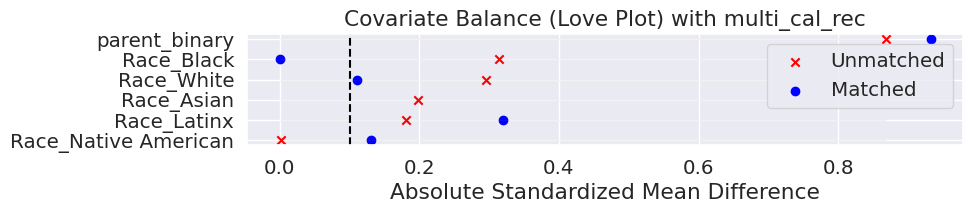

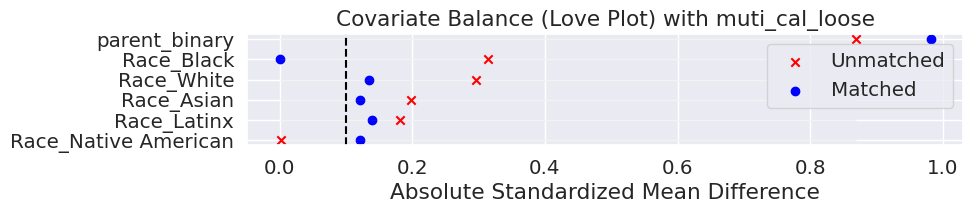

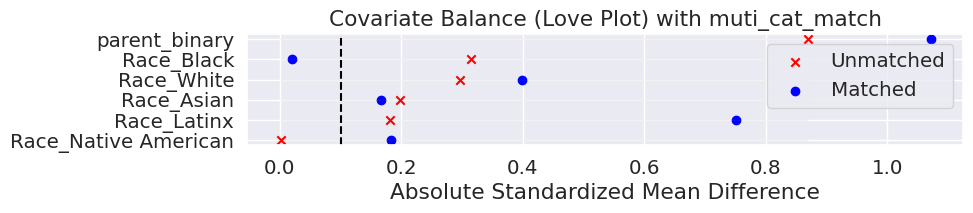

/tmp/ipykernel_5902/422276140.py:14: RuntimeWarning: invalid value encountered in scalar divide
  results[col] = np.abs(m1 - m0) / pooled_sd


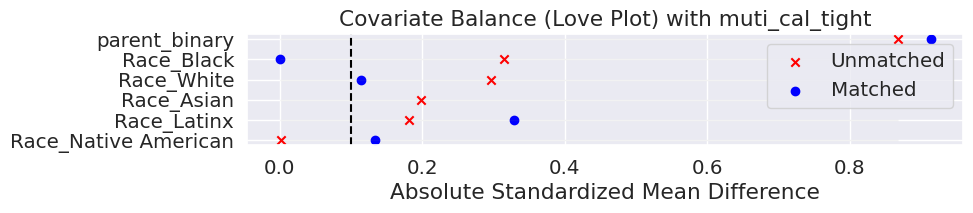

In [ ]:
vars_to_check = multi_category

# 1. Calculate for the raw data (before PSM)
smd_before = get_smds(crime, 'gender_woman', vars_to_check)

prop_match_options = ['multi_cal_rec', 'muti_cal_loose', 'muti_cat_match', 'muti_cal_tight']

for match_option in prop_match_options:
    # 2. Calculate for the matched pairs (after PSM)
  smd_after = get_smds(m[m[match_option]==True], 'def_woman', vars_to_check)

  plot_df = pd.DataFrame({
      'Variable': vars_to_check,
      'Unmatched': smd_before.values,
      'Matched': smd_after.values
  })

  df_sorted = plot_df.sort_values(by='Unmatched')

  plt.figure(figsize=(10, len(df_sorted) * 0.4)) # Scales height based on number of vars

  plt.scatter(df_sorted['Unmatched'], df_sorted['Variable'], color='red', label='Unmatched', marker='x')
  plt.scatter(df_sorted['Matched'], df_sorted['Variable'], color='blue', label='Matched', marker='o')

  # 2. Add a line for every variable to guide the eye
  plt.hlines(y=df_sorted['Variable'], xmin=0, xmax=df_sorted['Unmatched'].max(),
            color='gray', alpha=0.1, linewidth=1)

  plt.axvline(x=0.1, color='black', linestyle='--')
  plt.xlabel('Absolute Standardized Mean Difference')
  plt.title(f'Covariate Balance (Love Plot) with {match_option}')
  plt.legend()

  plt.tight_layout() # Prevents labels from getting cut off at the edge
  plt.show()

In [ ]:
multi = add_propensity(race_cols, 'gender_woman', ohe_meta, multi, 'multi_cal_rec_rep', cal=0.338364839705966, rep=True, h_m=2, add_score_col=False )


In [ ]:
multi[multi['psm_multi_cal_rec_rep']==True].def_woman.value_counts()

,count
def_woman,
False,92
True,46


In [ ]:
check_calipers_same_match(multi, 'psm_multi_cal_rec_rep','psm_multi_cal_rec_hm2')

True